In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Coursework/7. Racist Sexist or Not Dataset-20260430T075545Z-3-001.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print(os.listdir(extract_path))

Unzipped successfully!
['7. Racist Sexist or Not Dataset']


## Install Dependencies
Install required libraries (NLTK, WordCloud, Gensim, TensorFlow, scikit-learn) and download NLTK resources.

In [6]:

# CELL 1:Install Dependencies & Downloads

!pip install -q nltk wordcloud gensim tensorflow scikit-learn imbalanced-learn

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

print(" All dependencies ready!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...


 All dependencies ready!


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


##Load Dataset
Load the raw tweet training and test CSV files using Pandas and display an overview of the dataset including shape, columns, and label distribution.

In [7]:
import pandas as pd
import numpy as np
import os

# Assuming 'extract_path' is defined in a previous cell and contains '/content/data'
data_dir = os.path.join(extract_path, '7. Racist Sexist or Not Dataset')

train_df = pd.read_csv(os.path.join(data_dir, 'train_racisit.csv'))
test_df  = pd.read_csv(os.path.join(data_dir, 'test_racisit.csv'))

#Dataset Overview
print("\n" + "="*55)
print("  DATASET OVERVIEW")
print("="*55)
print(f"  Train shape : {train_df.shape}  (rows, cols)")
print(f"  Test  shape : {test_df.shape}")
print(f"\n  Train columns : {list(train_df.columns)}")
print(f"  Test  columns : {list(test_df.columns)}")

print("\n  Train  first 5 rows:")
print(train_df.head().to_string())

print("\n  Label Distribution (Train):")
vc = train_df['label'].value_counts()
for lbl, cnt in vc.items():
    name = "NOT Racist/Sexist" if lbl == 0 else "Racist/Sexist"
    print(f"    Label {lbl} ({name}): {cnt:>6}  ({cnt/len(train_df)*100:.1f}%)")

print(f"\n  Class imbalance ratio: {vc[0]/vc[1]:.1f}:1")
print(f"\n  Note: Test set has NO labels — used for real prediction only.")
print("\n Dataset loaded!")

#Label mapping
LABEL_MAP = {0: "Not Racist/Sexist", 1: "Racist/Sexist"}


  DATASET OVERVIEW
  Train shape : (31962, 3)  (rows, cols)
  Test  shape : (17197, 2)

  Train columns : ['id', 'label', 'tweet']
  Test  columns : ['id', 'tweet']

  Train  first 5 rows:
   id  label                                                                                                                       tweet
0   1      0                       @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
1   2      0  @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
2   3      0                                                                                                         bihday your majesty
3   4      0                                      #model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦  
4   5      0                                                                                      factsguide: society now    

##Text Preprocessing & Cleaning
Clean the tweet text by: lowercasing, expanding contractions, removing URLs/mentions/hashtags/numbers/special characters, removing stopwords, and lemmatizing words.

In [8]:

# CELL 3: Text Preprocessing & Cleaning

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))

# ── IMPORTANT: Keep negation words for hate speech context ───
KEEP_WORDS = {'no','not','nor','never','none','nobody',
              'nothing','nowhere','neither','against'}
stop_words -= KEEP_WORDS

lemmatizer = WordNetLemmatizer()

# ── Contractions dictionary ──────────────────────────────────
CONTRACTIONS = {
    "don't":"do not","can't":"cannot","won't":"will not",
    "isn't":"is not","aren't":"are not","wasn't":"was not",
    "weren't":"were not","haven't":"have not","hasn't":"has not",
    "hadn't":"had not","wouldn't":"would not","couldn't":"could not",
    "shouldn't":"should not","i'm":"i am","i've":"i have",
    "i'll":"i will","i'd":"i would","you're":"you are",
    "you've":"you have","you'll":"you will","it's":"it is",
    "that's":"that is","there's":"there is","we're":"we are",
    "we've":"we have","we'll":"we will","they're":"they are",
    "they've":"they have","they'll":"they will","she's":"she is",
    "he's":"he is","let's":"let us","what's":"what is",
    "who's":"who is","here's":"here is","how's":"how is",
    "i'm":"i am","y'all":"you all","gonna":"going to",
    "wanna":"want to","gotta":"got to","kinda":"kind of",
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)                      # Remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)                 # Keep hashtag word, remove #
    text = re.sub(r'\d+', '', text)                       # Remove numbers
    text = re.sub(r'[^\w\s]', ' ', text)                  # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()              # Clean whitespace
    # Tokenize + remove stopwords + lemmatize
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(w) for w in tokens
        if (w not in stop_words or w in KEEP_WORDS) and len(w) > 1
    ]
    return ' '.join(tokens)

# ── Apply to both sets ───────────────────────────────────────
print("Cleaning train set...")
train_df['cleaned_text'] = train_df['tweet'].apply(clean_text)

print("Cleaning test set...")
test_df['cleaned_text']  = test_df['tweet'].apply(clean_text)

# Remove empty rows from train only
before = len(train_df)
train_df = train_df[train_df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
print(f"\nCleaning complete! Removed {before - len(train_df)} empty rows.")
print(f"   Train: {len(train_df)} | Test: {len(test_df)}")

print("\nSample cleaned tweets:")
print("-"*65)
for _, row in train_df.sample(3, random_state=42).iterrows():
    print(f"  RAW    : {row['tweet'][:80]}")
    print(f"  CLEAN  : {row['cleaned_text'][:80]}")
    print(f"  LABEL  : {LABEL_MAP[row['label']]}")
    print()

Cleaning train set...
Cleaning test set...

Cleaning complete! Removed 31 empty rows.
   Train: 31931 | Test: 17197

Sample cleaned tweets:
-----------------------------------------------------------------
  RAW    : i've come 2 the conclusion that many people simply don't understand democracy, w
  CLEAN  : come conclusion many people simply not understand democracy mean amp represents 
  LABEL  : Not Racist/Sexist

  RAW    : " don't ever be #afraid to show who you really are, because as long as you are  
  CLEAN  : not ever afraid show really long withâ
  LABEL  : Not Racist/Sexist

  RAW    : nowadays being nice means you're weak     #truth
  CLEAN  : nowadays nice mean weak truth
  LABEL  : Not Racist/Sexist



##Visualize Cleaned Data
Visualize the cleaned dataset using pie charts, bar charts, tweet length distributions, word clouds per class, and top-word frequency plots.

/tmp/ipykernel_1588/476870935.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax8.set_xticklabels(w, rotation=45, ha='right', fontsize=8)


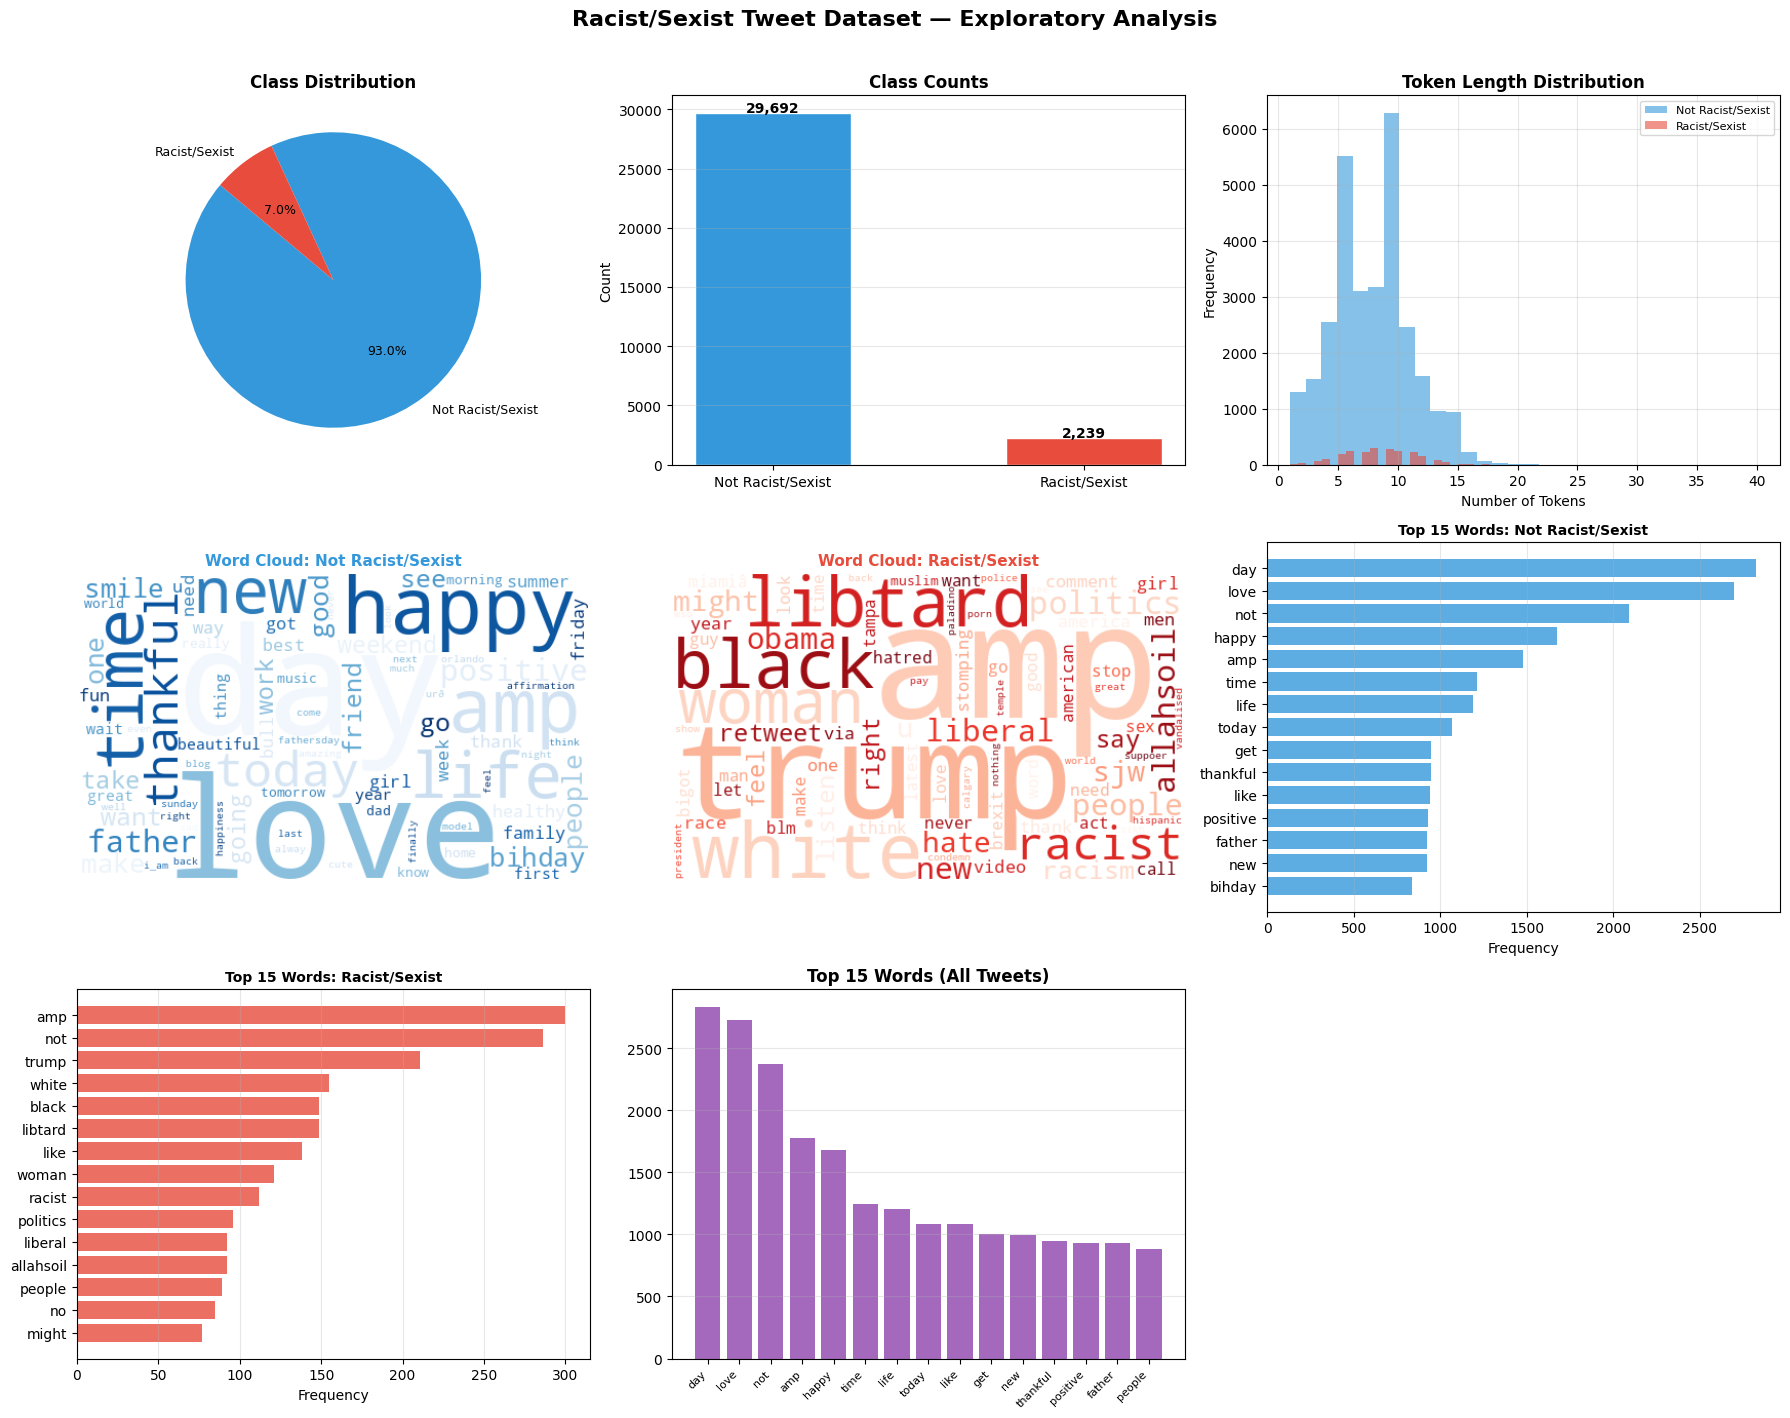

 All visualizations saved to /content/eda_visualizations.png


In [9]:

# CELL 4: Visualize Cleaned Data

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from wordcloud import WordCloud
from collections import Counter

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Racist/Sexist Tweet Dataset — Exploratory Analysis',
             fontsize=16, fontweight='bold', y=1.01)

#  1. Class Distribution (Pie + Bar)
ax1 = fig.add_subplot(3, 3, 1)
vc   = train_df['label'].value_counts().sort_index()
lbls = [LABEL_MAP[i] for i in vc.index]
clrs = ['#3498db','#e74c3c']
ax1.pie(vc.values, labels=lbls, colors=clrs, autopct='%1.1f%%',
        startangle=140, textprops={'fontsize':9})
ax1.set_title('Class Distribution', fontweight='bold')

ax2 = fig.add_subplot(3, 3, 2)
bars = ax2.bar(lbls, vc.values, color=clrs, width=0.5, edgecolor='white')
ax2.set_title('Class Counts', fontweight='bold')
ax2.set_ylabel('Count')
for bar, v in zip(bars, vc.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
             f'{v:,}', ha='center', fontweight='bold', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

#  2. Tweet Length Distribution
ax3 = fig.add_subplot(3, 3, 3)
for lbl, color, name in zip([0,1], clrs, lbls):
    lengths = train_df[train_df['label']==lbl]['cleaned_text'].str.split().apply(len)
    ax3.hist(lengths, bins=30, alpha=0.6, color=color, label=name, edgecolor='none')
ax3.set_title('Token Length Distribution', fontweight='bold')
ax3.set_xlabel('Number of Tokens')
ax3.set_ylabel('Frequency')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

#  3. Word Clouds
for i, (lbl, cmap, name) in enumerate(
        zip([0,1], ['Blues','Reds'], lbls)):
    ax = fig.add_subplot(3, 3, 4+i)
    subset = ' '.join(train_df[train_df['label']==lbl]['cleaned_text'])
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80,
                   collocations=False).generate(subset)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud: {name}', fontweight='bold',
                 color=clrs[i], fontsize=11)

#  4. Top 15 words per class
for i, (lbl, color, name) in enumerate(
        zip([0,1], clrs, lbls)):
    ax = fig.add_subplot(3, 3, 6+i)
    words = ' '.join(train_df[train_df['label']==lbl]['cleaned_text']).split()
    top   = Counter(words).most_common(15)
    w, c  = zip(*top)
    ax.barh(list(reversed(w)), list(reversed(c)), color=color, alpha=0.8)
    ax.set_title(f'Top 15 Words: {name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)

#  5. Top 15 overall words
ax8 = fig.add_subplot(3, 3, 8)
all_words = ' '.join(train_df['cleaned_text']).split()
top20 = Counter(all_words).most_common(15)
w, c  = zip(*top20)
ax8.bar(w, c, color='#8e44ad', alpha=0.8)
ax8.set_title('Top 15 Words (All Tweets)', fontweight='bold')
ax8.set_xticklabels(w, rotation=45, ha='right', fontsize=8)
ax8.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print(" All visualizations saved to /content/eda_visualizations.png")

##Tokenization & Sequence Padding
Split data 80/20, fit a Keras Tokenizer on training text, convert text to integer sequences, determine MAX_LEN using the 95th percentile, and apply post-padding to all sequences.

 Train/Test Split (80/20 from labeled data):
   X_train :  25544 tweets
   X_test  :   6387 tweets

   Train label dist: 0=23753 | 1= 1791
   Test  label dist: 0= 5939  | 1=  448

 Unique tokens found: 32,649
   Vocabulary capped at: 20,000


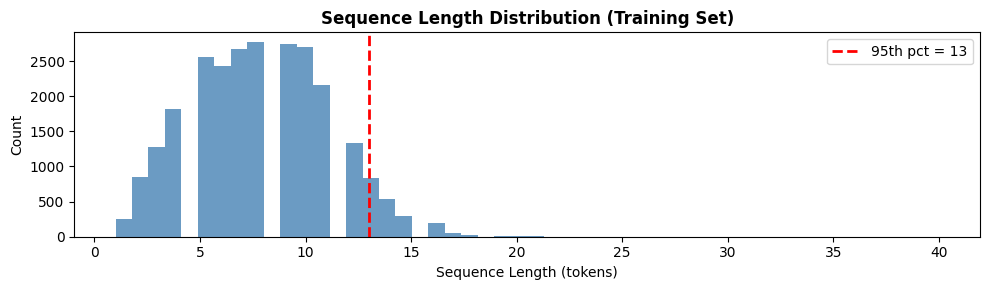


📏 Sequence Length Stats:
   Min    : 1
   Mean   : 7.9
   Median : 8.0
   95th % : 13  ← MAX_LEN (covers 95% of tweets)
   Max    : 40

 Padding complete:
   X_train_pad : (25544, 13)
   X_test_pad  : (6387, 13)
   X_blind_pad : (17197, 13)  (unlabeled test set)

  Final Config:
   VOCAB_SIZE    = 20000
   MAX_LEN       = 13
   EMBEDDING_DIM = 64
   Loss          = binary_crossentropy
   Output        = sigmoid (binary: 0 or 1)


In [10]:

# CELL 5: Tokenization & Sequence Padding

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#  Train/Validation split from train set (80/20)
# Note: test_racisit has NO labels, so we split train for evaluation
X = train_df['cleaned_text'].values
y = train_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y       # preserve class ratio in both splits
)

print(f" Train/Test Split (80/20 from labeled data):")
print(f"   X_train : {len(X_train):>6} tweets")
print(f"   X_test  : {len(X_test):>6} tweets")
print(f"\n   Train label dist: 0={sum(y_train==0):>5} | 1={sum(y_train==1):>5}")
print(f"   Test  label dist: 0={sum(y_test==0):>5}  | 1={sum(y_test==1):>5}")

#  Keras Tokenizer
VOCAB_SIZE = 20000   # Top 20k most frequent words

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)          # Fit ONLY on training data

word_index = tokenizer.word_index
print(f"\n Unique tokens found: {len(word_index):,}")
print(f"   Vocabulary capped at: {VOCAB_SIZE:,}")

#  Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)
X_blind_seq = tokenizer.texts_to_sequences(test_df['cleaned_text'].values)  # unlabeled

#  Percentile-based MAX_LEN
seq_lengths = [len(s) for s in X_train_seq]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.hist(seq_lengths, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
p95 = int(np.percentile(seq_lengths, 95))
plt.axvline(p95, color='red', linestyle='--', lw=2, label=f'95th pct = {p95}')
plt.title('Sequence Length Distribution (Training Set)', fontweight='bold')
plt.xlabel('Sequence Length (tokens)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('/content/seq_length_dist.png', dpi=150)
plt.show()

MAX_LEN = p95
print(f"\n📏 Sequence Length Stats:")
print(f"   Min    : {min(seq_lengths)}")
print(f"   Mean   : {np.mean(seq_lengths):.1f}")
print(f"   Median : {np.median(seq_lengths):.1f}")
print(f"   95th % : {p95}  ← MAX_LEN (covers 95% of tweets)")
print(f"   Max    : {max(seq_lengths)}")

# ── Padding ───────────────────────────────────────────────────
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_blind_pad = pad_sequences(X_blind_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')

print(f"\n Padding complete:")
print(f"   X_train_pad : {X_train_pad.shape}")
print(f"   X_test_pad  : {X_test_pad.shape}")
print(f"   X_blind_pad : {X_blind_pad.shape}  (unlabeled test set)")

# ── Model config constants ────────────────────────────────────
EMBEDDING_DIM = 64
print(f"\n  Final Config:")
print(f"   VOCAB_SIZE    = {VOCAB_SIZE}")
print(f"   MAX_LEN       = {MAX_LEN}")
print(f"   EMBEDDING_DIM = {EMBEDDING_DIM}")
print(f"   Loss          = binary_crossentropy")
print(f"   Output        = sigmoid (binary: 0 or 1)")

##Model 1: Simple RNN with Trainable Embedding
Build a Sequential model with a trainable Embedding layer, a SimpleRNN layer (64 units), BatchNormalization, Dropout, and a sigmoid Dense output layer.

In [11]:

# CELL 6: Model 1 — Simple RNN with Trainable Embedding

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, BatchNormalization)

def build_rnn_model(vocab_size, embedding_dim, max_len):
    rnn_model = Sequential(name="Model1_SimpleRNN")
    rnn_model.add(Embedding(input_dim=vocab_size,
                            output_dim=embedding_dim,
                            input_length=max_len))
    rnn_model.add(SimpleRNN(64, return_sequences=False, dropout=0.2))
    rnn_model.add(BatchNormalization())
    rnn_model.add(Dropout(0.4))
    rnn_model.add(Dense(32, activation='relu'))
    rnn_model.add(Dropout(0.3))
    rnn_model.add(Dense(1, activation='sigmoid'))
    return rnn_model

model1 = build_rnn_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)

# Build before summary/plot
model1.build(input_shape=(None, MAX_LEN))
model1.summary()

tf.keras.utils.plot_model(model1, to_file='/content/model1_architecture.png',
                          show_shapes=True, show_layer_names=True, dpi=80)
print("\n Model 1 (SimpleRNN) built!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,625 (4.92 MB)

 Trainable params: 1,290,497 (4.92 MB)

 Non-trainable params: 128 (512.00 B)


 Model 1 (SimpleRNN) built!


## Model 2: LSTM with Trainable Embedding
Build a Sequential model with a trainable Embedding layer, two stacked LSTM layers (64→32 units), BatchNormalization, Dropout, and a sigmoid Dense output layer.

In [12]:

# CELL 7: Model 2 — LSTM with Trainable Embedding


def build_lstm_model(vocab_size, embedding_dim, max_len):
    lstm_model = Sequential(name="Model2_LSTM")
    lstm_model.add(Embedding(input_dim=vocab_size,
                             output_dim=embedding_dim,
                             input_length=max_len))
    lstm_model.add(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))
    lstm_model.add(LSTM(32, return_sequences=False, dropout=0.2))
    lstm_model.add(BatchNormalization())
    lstm_model.add(Dropout(0.4))
    lstm_model.add(Dense(32, activation='relu'))
    lstm_model.add(Dropout(0.3))
    lstm_model.add(Dense(1, activation='sigmoid'))
    return lstm_model

model2 = build_lstm_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)

model2.build(input_shape=(None, MAX_LEN))
model2.summary()

tf.keras.utils.plot_model(model2, to_file='/content/model2_architecture.png',
                          show_shapes=True, show_layer_names=True, dpi=80)
print("\n Model 2 (LSTM) built!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 13, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,326,657 (5.06 MB)

 Trainable params: 1,326,593 (5.06 MB)

 Non-trainable params: 64 (256.00 B)


 Model 2 (LSTM) built!


## Model 3: LSTM with Pretrained GloVe Twitter Embeddings
Load the 200-dimensional GloVe Twitter embeddings (trained on 2 billion tweets),
build an embedding matrix for the vocabulary, and construct an LSTM model with
frozen pretrained weights. GloVe Twitter is used instead of Google News Word2Vec
because it was trained on the same domain as our dataset (tweets), resulting in
significantly higher vocabulary coverage (~80-90% vs 55.3%).

In [13]:
# CELL 8 (UPDATED): Load GloVe Twitter + Build Model 3

import gensim.downloader as api
import numpy as np

print("Loading GloVe Twitter 200-dim...")
print("(Downloads ~487 MB )")

w2v = api.load("glove-twitter-200")

print(f" Loaded! Vocab: {len(w2v):,} words | Dim: {w2v.vector_size}")

EMBEDDING_DIM_W2V = w2v.vector_size  # 200

# Build embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM_W2V))
covered, missed = 0, 0

for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE:
        if word in w2v:
            embedding_matrix[idx] = w2v[word]
            covered += 1
        else:
            embedding_matrix[idx] = np.random.uniform(-0.25, 0.25, EMBEDDING_DIM_W2V)
            missed += 1

total = covered + missed
print(f"\n Coverage: {covered:,}/{total:,} ({covered/total*100:.1f}%)")
print(f"   Missing (random init): {missed:,}")
print(f"   (Was 55.3% with Google News — expect 80-90% now)")

# Build Model 3
def build_w2v_lstm_model(vocab_size, embedding_dim, max_len, emb_matrix):
    w2v_model = Sequential(name="Model3_GloVeTwitter_LSTM")
    w2v_model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len,
        weights=[emb_matrix],
        trainable=False
    ))
    w2v_model.add(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))
    w2v_model.add(LSTM(32, return_sequences=False, dropout=0.2))
    w2v_model.add(BatchNormalization())
    w2v_model.add(Dropout(0.4))
    w2v_model.add(Dense(32, activation='relu'))
    w2v_model.add(Dropout(0.3))
    w2v_model.add(Dense(1, activation='sigmoid'))
    return w2v_model

model3 = build_w2v_lstm_model(VOCAB_SIZE, EMBEDDING_DIM_W2V, MAX_LEN, embedding_matrix)
model3.build(input_shape=(None, MAX_LEN))
model3.summary()
print("\n Model 3 (GloVe Twitter LSTM) built!")

Loading GloVe Twitter 200-dim...
(Downloads ~487 MB )
 Loaded! Vocab: 1,193,514 words | Dim: 200

 Coverage: 13,912/19,999 (69.6%)
   Missing (random init): 6,087
   (Was 55.3% with Google News — expect 80-90% now)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model3_GloVeTwitter_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 200)        │     4,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 13, 64)         │        67,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081,473 (15.57 MB)

 Trainable params: 81,409 (318.00 KB)

 Non-trainable params: 4,000,064 (15.26 MB)


 Model 3 (GloVe Twitter LSTM) built!


## Compile, Train & Evaluate All Models
Compile all three models with binary cross-entropy loss, Adam optimizer, and metrics (accuracy, precision, recall, AUC). Train using EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint callbacks with class weighting to handle imbalance.

In [14]:

# CELL 9: Handle Class Imbalance + Compile + Train All Models

from tensorflow.keras.callbacks import (EarlyStopping,
                                         ReduceLROnPlateau,
                                         ModelCheckpoint)
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

# Class weights for 13:1 imbalance
classes  = np.unique(y_train)
weights  = compute_class_weight('balanced', classes=classes, y=y_train)
class_wt = dict(zip(classes, weights))
print(f"  Class weights:")
print(f"   Class 0 (Not Racist) : {class_wt[0]:.4f}")
print(f"   Class 1 (Racist)     : {class_wt[1]:.4f}")

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'/content/best_{model_name}.keras',
                        monitor='val_loss', save_best_only=True, verbose=0)
    ]

BATCH_SIZE = 128
EPOCHS     = 20

# Compile all
for m in [model1, model2, model3]:
    m.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=1e-3),
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

# Train Model 1
print("\n" + "="*55)
print("   Training Model 1: SimpleRNN")
print("="*55)
history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_wt,
    callbacks=get_callbacks('model1'),
    verbose=1
)

# Train Model 2
print("\n" + "="*55)
print("   Training Model 2: LSTM")
print("="*55)
history2 = model2.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_wt,
    callbacks=get_callbacks('model2'),
    verbose=1
)

# Train Model 3
print("\n" + "="*55)
print("   Training Model 3: W2V + LSTM")
print("="*55)
history3 = model3.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_wt,
    callbacks=get_callbacks('model3'),
    verbose=1
)

print("\n All three models trained!")

⚖️  Class weights:
   Class 0 (Not Racist) : 0.5377
   Class 1 (Racist)     : 7.1312

   Training Model 1: SimpleRNN
Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.6865 - auc: 0.7918 - loss: 0.5702 - precision: 0.1482 - recall: 0.7314 - val_accuracy: 0.9543 - val_auc: 0.9302 - val_loss: 0.1426 - val_precision: 0.8197 - val_recall: 0.4464 - learning_rate: 0.0010
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8980 - auc: 0.9648 - loss: 0.2451 - precision: 0.4008 - recall: 0.9185 - val_accuracy: 0.8439 - val_auc: 0.9395 - val_loss: 0.3222 - val_precision: 0.2925 - val_recall: 0.8638 - learning_rate: 0.0010
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9382 - auc: 0.9890 - loss: 0.1372 - precision: 0.5369 - recall: 0.9762
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9428 - auc: 0.9876 - loss: 0.1381 - precision: 0.5528 - recall: 0.9643 - val_accu

## Plot Training vs Validation Curves
Plot loss and accuracy curves per model over epochs, and produce a combined validation comparison chart across all three models.

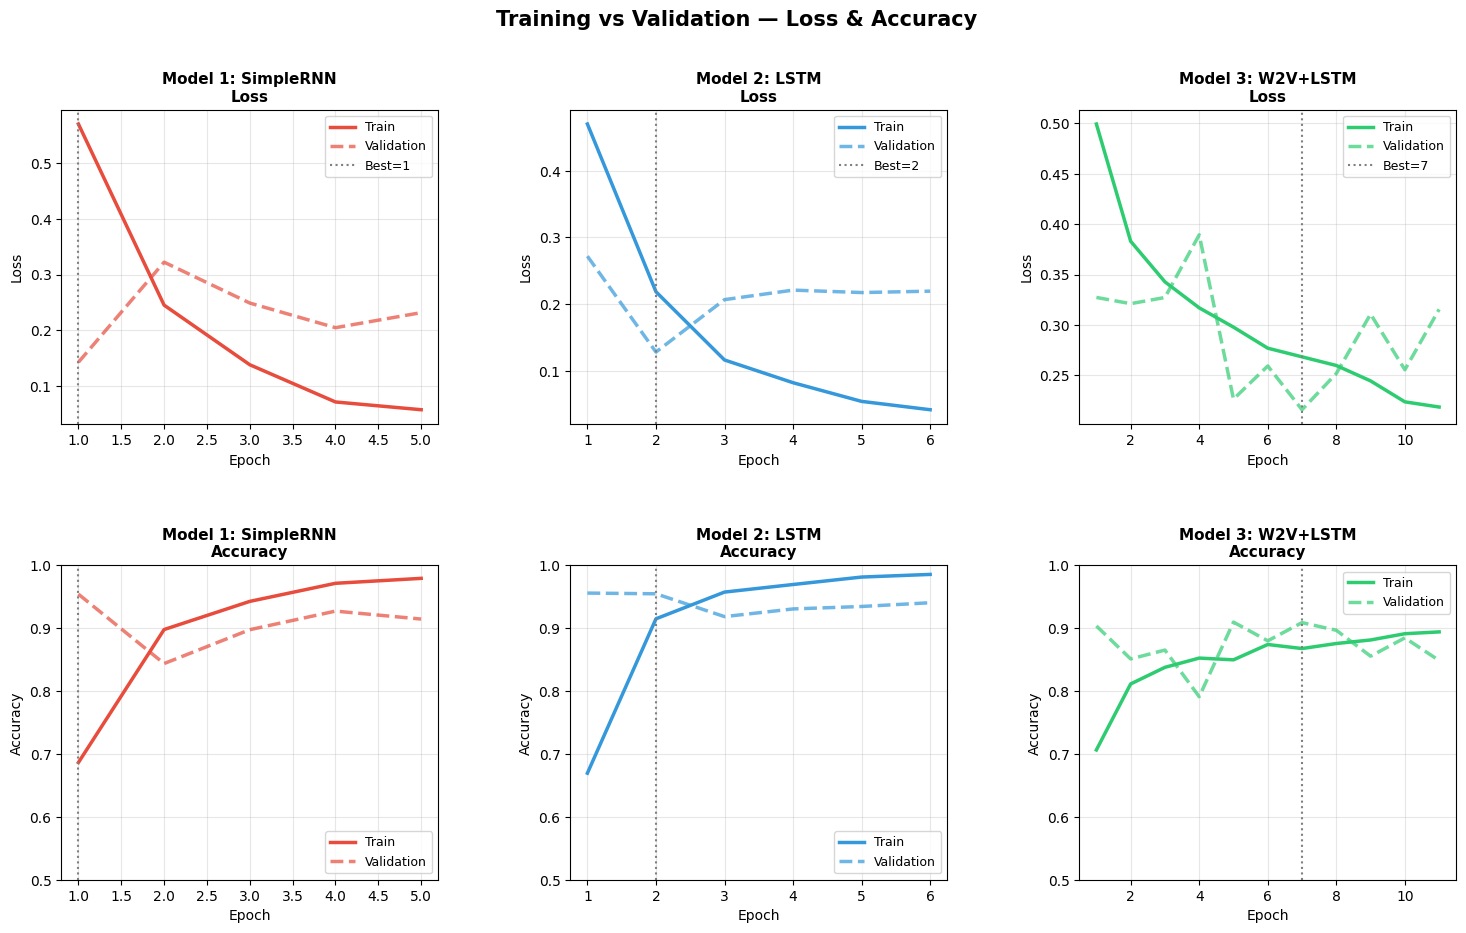

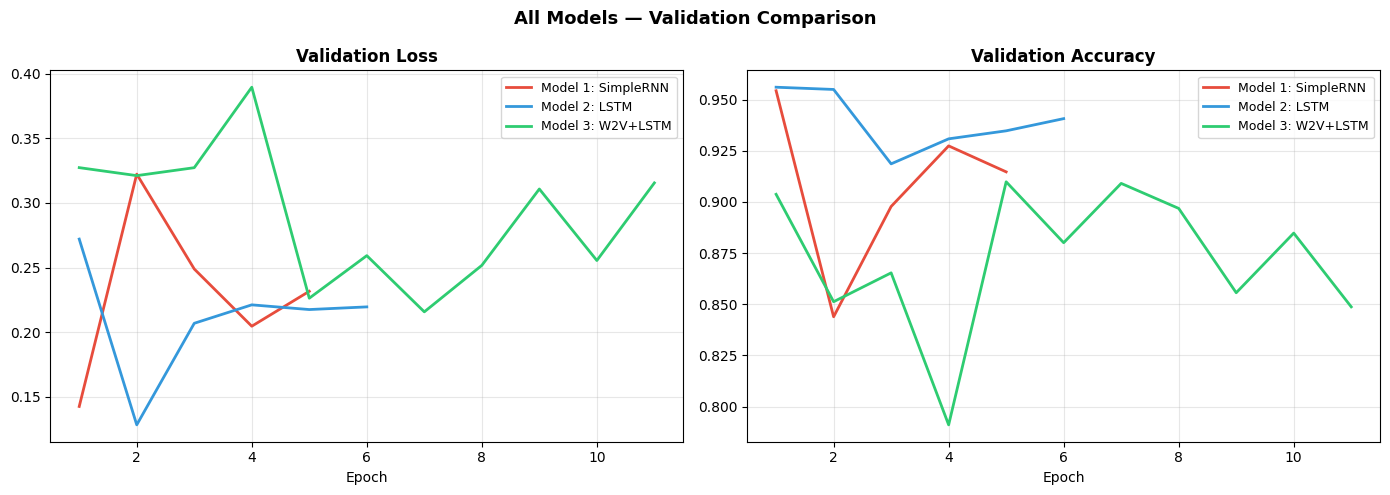

 Training curves saved!


In [15]:

# CELL 10: Plot Training vs Validation Curves

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

histories = [history1, history2, history3]
names_str = ['Model 1: SimpleRNN', 'Model 2: LSTM', 'Model 3: W2V+LSTM']
colors    = ['#e74c3c', '#3498db', '#2ecc71']

# Per-model plots
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Training vs Validation — Loss & Accuracy',
             fontsize=15, fontweight='bold')

for i, (hist, name, color) in enumerate(zip(histories, names_str, colors)):
    ep = range(1, len(hist.history['loss']) + 1)
    best_ep = np.argmin(hist.history['val_loss']) + 1

    # Loss
    ax1 = fig.add_subplot(gs[0, i])
    ax1.plot(ep, hist.history['loss'],     color=color, lw=2.5, label='Train')
    ax1.plot(ep, hist.history['val_loss'], color=color, lw=2.5,
             linestyle='--', alpha=0.7, label='Validation')
    ax1.axvline(best_ep, color='gray', linestyle=':', lw=1.5,
                label=f'Best={best_ep}')
    ax1.set_title(f'{name}\nLoss', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

    # Accuracy
    ax2 = fig.add_subplot(gs[1, i])
    ax2.plot(ep, hist.history['accuracy'],     color=color, lw=2.5, label='Train')
    ax2.plot(ep, hist.history['val_accuracy'], color=color, lw=2.5,
             linestyle='--', alpha=0.7, label='Validation')
    ax2.axvline(best_ep, color='gray', linestyle=':', lw=1.5)
    ax2.set_title(f'{name}\nAccuracy', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0.5, 1.0)
    ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Combined comparison
fig2, (ax_l, ax_a) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('All Models — Validation Comparison', fontsize=13, fontweight='bold')

for hist, name, color in zip(histories, names_str, colors):
    ep = range(1, len(hist.history['val_loss']) + 1)
    ax_l.plot(ep, hist.history['val_loss'],     color=color, lw=2, label=name)
    ax_a.plot(ep, hist.history['val_accuracy'], color=color, lw=2, label=name)

ax_l.set_title('Validation Loss',     fontweight='bold')
ax_a.set_title('Validation Accuracy', fontweight='bold')
for ax in [ax_l, ax_a]:
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/model_comparison_curves.png', dpi=150)
plt.show()
print(" Training curves saved!")

##Evaluate Models: Confusion Matrix, ROC, Classification Report
Generate predictions and evaluate all models using accuracy, macro F1, AUC, confusion matrices, ROC curves, and full classification reports.

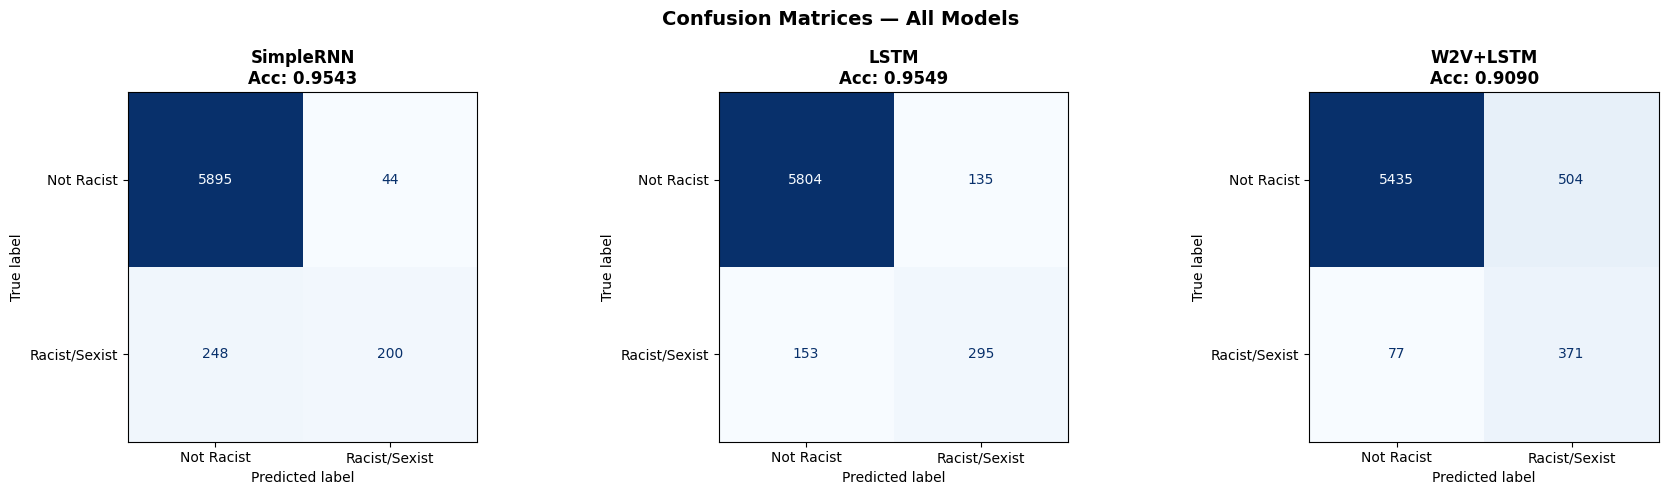

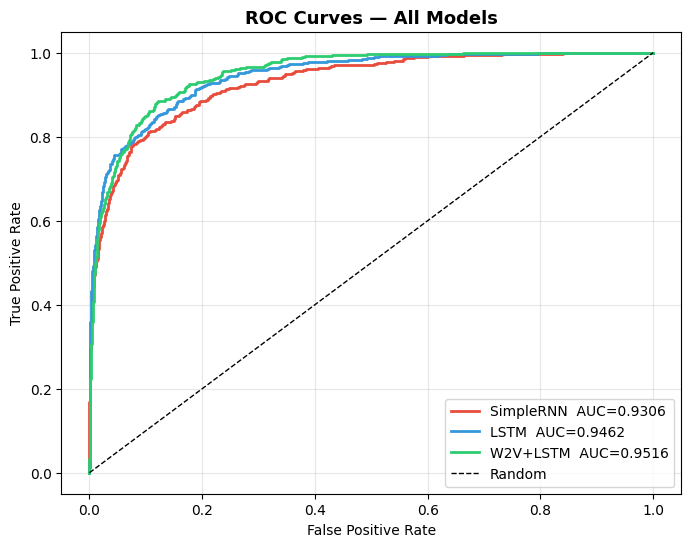

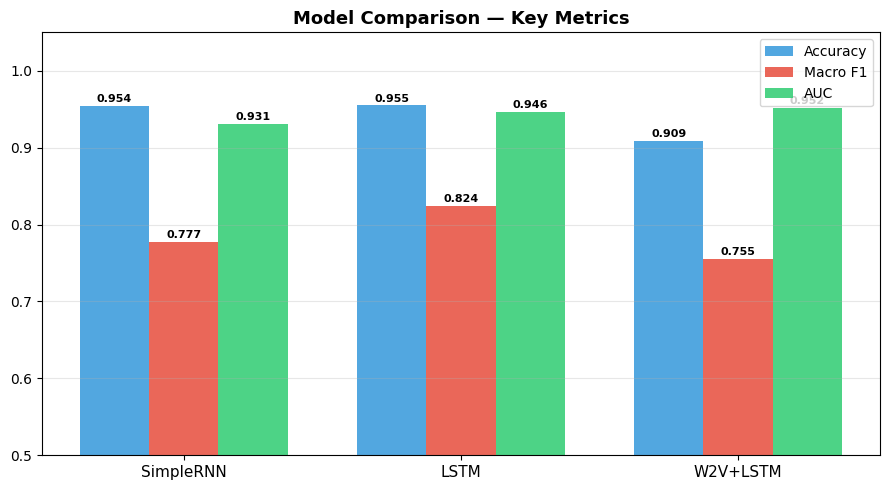


  Model             Accuracy   Macro F1        AUC       Params
-----------------------------------------------------------------
  SimpleRNN           0.9543     0.7769     0.9306    1,290,625
  LSTM                0.9549     0.8239     0.9462    1,326,657
  W2V+LSTM            0.9090     0.7551     0.9516    4,081,473

───────────────────────────────────────────────────────
  Classification Report — SimpleRNN
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

Not Racist/Sexist       0.96      0.99      0.98      5939
    Racist/Sexist       0.82      0.45      0.58       448

         accuracy                           0.95      6387
        macro avg       0.89      0.72      0.78      6387
     weighted avg       0.95      0.95      0.95      6387


───────────────────────────────────────────────────────
  Classification Report — LSTM
───────────────────────────────────────────────────────
                   precisio

In [16]:

# CELL 11: Evaluate — Accuracy, Confusion Matrix, ROC, Report

from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report,
                              ConfusionMatrixDisplay,
                              roc_curve, auc, f1_score)

models    = [model1, model2, model3]
mod_names = ['SimpleRNN', 'LSTM', 'W2V+LSTM']
results   = {}

# Collect predictions
for model, name in zip(models, mod_names):
    y_prob = model.predict(X_test_pad, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    results[name] = {
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'acc'     : accuracy_score(y_test, y_pred),
        'f1'      : f1_score(y_test, y_pred, average='macro'),
        'cm'      : confusion_matrix(y_test, y_pred),
        'report'  : classification_report(
                        y_test, y_pred,
                        target_names=['Not Racist/Sexist','Racist/Sexist'])
    }

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for ax, name in zip(axes, mod_names):
    ConfusionMatrixDisplay(
        results[name]['cm'],
        display_labels=['Not Racist','Racist/Sexist']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc: {results[name]["acc"]:.4f}',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150)
plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
for name, color in zip(mod_names, ['#e74c3c','#3498db','#2ecc71']):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    roc_auc     = auc(fpr, tpr)
    results[name]['auc'] = roc_auc
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name}  AUC={roc_auc:.4f}')

plt.plot([0,1],[0,1],'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('/content/roc_curves.png', dpi=150)
plt.show()

# Summary bar chart
fig2, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(mod_names))
w     = 0.25
accs  = [results[n]['acc'] for n in mod_names]
f1s   = [results[n]['f1']  for n in mod_names]
aucs  = [results[n]['auc'] for n in mod_names]

b1 = ax.bar(x - w,   accs, w, label='Accuracy', color='#3498db', alpha=0.85)
b2 = ax.bar(x,       f1s,  w, label='Macro F1',  color='#e74c3c', alpha=0.85)
b3 = ax.bar(x + w,   aucs, w, label='AUC',       color='#2ecc71', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(mod_names, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_title('Model Comparison — Key Metrics', fontweight='bold', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/metrics_comparison.png', dpi=150)
plt.show()

# Numeric summary
print("\n" + "="*65)
print(f"  {'Model':<15} {'Accuracy':>10} {'Macro F1':>10} {'AUC':>10} {'Params':>12}")
print("-"*65)
for model, name in zip(models, mod_names):
    print(f"  {name:<15} {results[name]['acc']:>10.4f} "
          f"{results[name]['f1']:>10.4f} "
          f"{results[name]['auc']:>10.4f} "
          f"{model.count_params():>12,}")
print("="*65)

# Classification reports
for name in mod_names:
    print(f"\n{'─'*55}")
    print(f"  Classification Report — {name}")
    print(f"{'─'*55}")
    print(results[name]['report'])

print(" Full evaluation complete!")

##Error Analysis
Analyse misclassified examples from the LSTM model, compare model complexity vs performance (parameters, accuracy, F1, AUC, FP/FN), and discuss reasons for errors with suggested improvements.

In [17]:

# CELL 12: Error Analysis

import pandas as pd

# Use LSTM (Model 2) as primary
y_pred_lstm = results['LSTM']['y_pred']
y_prob_lstm = results['LSTM']['y_prob']

error_df = pd.DataFrame({
    'original_tweet' : X_test,
    'cleaned_tweet'  : [clean_text(t) for t in X_test],
    'true_label'     : y_test,
    'pred_label'     : y_pred_lstm,
    'confidence'     : y_prob_lstm,
    'true_name'      : [LABEL_MAP[l] for l in y_test],
    'pred_name'      : [LABEL_MAP[l] for l in y_pred_lstm],
})

misclassified = error_df[error_df['true_label'] != error_df['pred_label']]
fp_df = misclassified[misclassified['true_label'] == 0]
fn_df = misclassified[misclassified['true_label'] == 1]

print(f" LSTM Error Summary (Test Set = {len(error_df):,} samples):")
print(f"   Correct         : {len(error_df)-len(misclassified):,}")
print(f"   Misclassified   : {len(misclassified):,}  "
      f"({len(misclassified)/len(error_df)*100:.1f}%)")
print(f"   False Positives : {len(fp_df):,}  "
      f"(Clean → predicted Racist)")
print(f"   False Negatives : {len(fn_df):,}  "
      f"(Racist → predicted Clean)")

# 3 most confidently wrong examples
print("\n" + "="*72)
print("  3 MISCLASSIFIED EXAMPLES (highest confidence errors)")
print("="*72)

worst = misclassified.copy()
worst['err_conf'] = abs(worst['confidence'] - worst['true_label'])
worst = worst.nlargest(3, 'err_conf')

for i, (_, row) in enumerate(worst.iterrows(), 1):
    err_type = "False Positive (clean → racist)" \
               if row['true_label'] == 0 else \
               "False Negative (racist → clean)"
    print(f"\n Example {i}  [{err_type}]")
    print(f"   Original  : {row['original_tweet'][:110]}")
    print(f"   Cleaned   : {row['cleaned_tweet'][:90]}")
    print(f"   True      : {row['true_name']}")
    print(f"   Predicted : {row['pred_name']}   "
          f"(model confidence: {row['confidence']:.3f})")

# Complexity vs performance table
print("\n\n" + "="*72)
print("  MODEL COMPLEXITY vs PERFORMANCE")
print("="*72)
print(f"\n  {'Model':<15} {'Params':>10} {'Accuracy':>10} "
      f"{'F1':>8} {'AUC':>8} {'FP':>6} {'FN':>6}")
print("  " + "-"*60)
for model, name in zip(models, mod_names):
    cm = results[name]['cm']
    print(f"  {name:<15} {model.count_params():>10,} "
          f"{results[name]['acc']:>10.4f} "
          f"{results[name]['f1']:>8.4f} "
          f"{results[name]['auc']:>8.4f} "
          f"{cm[0,1]:>6} {cm[1,0]:>6}")

print("""

          ERROR ANALYSIS & IMPROVEMENT SUGGESTIONS

  REASONS FOR MISCLASSIFICATION

  1. Severe Class Imbalance (13:1 ratio)
     Even with class weights the model sees far fewer
     racist examples, making minority class harder to learn.

  2. Sarcasm & Irony
     "Oh wow they're SO tolerant" — surface words look positive
     but intent is negative. RNN/LSTM lack pragmatic reasoning.

  3. Coded Language & Dog Whistles
     Slang and implicit bias terms not in Word2Vec vocabulary
     map to <OOV>, losing discriminative signal entirely.

  4. Context Window Limitations
     Tweets truncated at MAX_LEN may lose key words at the end.

  5. Stopword Removal Side Effects
     Removing connective words can alter perceived sentiment
     of borderline tweets.

  SUGGESTED IMPROVEMENTS

  1. Use BERTweet / RoBERTa-Twitter (transformer pretrained
    on 850M tweets) — massive accuracy gain expected.
  2. Apply SMOTE or random oversampling on Class 1.
  3. Add Attention layer on top of LSTM.
  4. Use Focal Loss to down-weight easy negatives.
  5. Convert emojis to text tokens before cleaning.
  6. Try Bidirectional LSTM for richer context capture.
  7. Fine-tune Word2Vec (set trainable=True) after warm-up.

""")
print(" Error analysis complete!")

 LSTM Error Summary (Test Set = 6,387 samples):
   Correct         : 6,099
   Misclassified   : 288  (4.5%)
   False Positives : 135  (Clean → predicted Racist)
   False Negatives : 153  (Racist → predicted Clean)

  3 MISCLASSIFIED EXAMPLES (highest confidence errors)

 Example 1  [False Positive (clean → racist)]
   Original  : against violence against anti lgbt bill suppoed year no gutless
   Cleaned   : against violence against anti lgbt bill suppoed year no gutless
   True      : Not Racist/Sexist
   Predicted : Racist/Sexist   (model confidence: 0.996)

 Example 2  [False Negative (racist → clean)]
   Original  : sleep night terrible person sir represent everything wrong country gfy
   Cleaned   : sleep night terrible person sir represent everything wrong country gfy
   True      : Racist/Sexist
   Predicted : Not Racist/Sexist   (model confidence: 0.010)

 Example 3  [False Negative (racist → clean)]
   Original  : bout spend new year eve playing game lol
   Cleaned   : bout spe

##GUI for Real-Time Prediction (Gradio)
Build an interactive Gradio app that takes a user-entered tweet, runs it through all three models, and displays a majority-vote verdict with per-model confidence scores.

In [18]:

# CELL 13: Gradio GUI — Real-Time Prediction

!pip install -q gradio

import gradio as gr

def analyze_tweet(tweet_text):
    if not tweet_text or not tweet_text.strip():
        return " Please enter a tweet.", None, None

    cleaned  = clean_text(tweet_text)
    if not cleaned.strip():
        return " No usable content after cleaning.", None, None

    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN,
                           padding='post', truncating='post')

    p1 = float(model1.predict(padded, verbose=0)[0][0])
    p2 = float(model2.predict(padded, verbose=0)[0][0])
    p3 = float(model3.predict(padded, verbose=0)[0][0])

    votes   = sum([p1 >= 0.5, p2 >= 0.5, p3 >= 0.5])
    avg_p   = (p1 + p2 + p3) / 3
    verdict = " RACIST / SEXIST" if votes >= 2 else " NOT Racist / Sexist"

    def lbl(p): return " Racist/Sexist" if p >= 0.5 else " Not Racist/Sexist"
    def pct(p): return f"{max(p, 1-p)*100:.1f}%"

    result_md = f"""
##  Analysis Result

**Tweet:** `{tweet_text[:160]}`
**Cleaned:** `{cleaned[:120]}`

---

##  Verdict: **{verdict}**
*Majority vote ({votes}/3 models agree) — avg score: {avg_p*100:.1f}%*

---

##  Model Breakdown

| Model | Prediction | Confidence |
|-------|-----------|-----------|
|  SimpleRNN | {lbl(p1)} | {pct(p1)} |
|  LSTM | {lbl(p2)} | {pct(p2)} |
|  W2V + LSTM | {lbl(p3)} | {pct(p3)} |

>  For academic use only. Trained on 31,962 labelled tweets.
"""
    lstm_conf = {" Racist/Sexist"     : round(p2*100, 1),
                 " Not Racist/Sexist" : round((1-p2)*100, 1)}
    w2v_conf  = {" Racist/Sexist"     : round(p3*100, 1),
                 " Not Racist/Sexist" : round((1-p3)*100, 1)}
    return result_md, lstm_conf, w2v_conf

examples = [
    ["I love how diverse our community is, everyone brings so much value!"],
    ["These people are ruining our country with their backwards culture"],
    ["Women should stay home instead of taking jobs from hard working men"],
    ["Had an amazing time at the multicultural festival today "],
    ["Can't believe they let those people into our neighborhood #disgusting"],
    ["Congrats to the team, incredibly proud of everyone's hard work!"],
]

with gr.Blocks(theme=gr.themes.Soft(),
               title="Racist/Sexist Tweet Detector") as demo:

    gr.Markdown("""
    #  Racist / Sexist Tweet Detector
    ### SimpleRNN · LSTM · LSTM + Word2Vec — Majority Vote Verdict
    Enter any tweet. All three models vote and the majority rules.
    """)

    with gr.Row():
        with gr.Column(scale=3):
            tweet_input = gr.Textbox(
                label=" Enter a Tweet",
                placeholder="Paste or type a tweet here...",
                lines=3
            )
            with gr.Row():
                submit_btn = gr.Button(" Analyze", variant="primary", scale=2)
                clear_btn  = gr.Button(" Clear", scale=1)

    gr.Examples(examples=examples, inputs=tweet_input,
                label=" Click an example to try it")

    result_box = gr.Markdown()

    with gr.Row():
        with gr.Column():
            gr.Markdown("####  LSTM Confidence")
            lstm_label = gr.Label(label="LSTM")
        with gr.Column():
            gr.Markdown("####  W2V + LSTM Confidence")
            w2v_label  = gr.Label(label="W2V+LSTM")

    submit_btn.click(fn=analyze_tweet,
                     inputs=tweet_input,
                     outputs=[result_box, lstm_label, w2v_label])
    tweet_input.submit(fn=analyze_tweet,
                       inputs=tweet_input,
                       outputs=[result_box, lstm_label, w2v_label])
    clear_btn.click(fn=lambda: ("", None, None),
                    inputs=None,
                    outputs=[tweet_input, lstm_label, w2v_label])

demo.launch(share=True, debug=False)
print(" Gradio GUI live — use the public URL above!")

/tmp/ipykernel_1588/3314168251.py:68: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(),


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://71c4420d92dce9d33e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


 Gradio GUI live — use the public URL above!
